In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
# Bu sətr vizuallaşdırma qrafiklərinin xarici görünüşünü və stilini tənzimləmək üçün istifadə edilir.

In [2]:
# Burada 25 ədəd detalın Brinell bərklik ölçmə nəticəsi verilmişdir.

data = np.array([
    170, 167, 174, 179, 179, 187, 179, 183, 179, 156,
    163, 156, 187, 156, 167, 156, 174, 170, 183, 179,
    174, 179, 170, 159, 187
])

In [3]:
# Birinci addımda təsviri statistika parametrlərini hesablayırıq:

n = len(data)  # Seçim həcmi
mean = np.mean(data)  # Seçim ortalaması
std = np.std(data)  # Seçimin standart meyletməsi
se = std/np.sqrt(n)  # Seçimin standart xətası

print('=== 1. Descriptive Statistics ===')
print(f"Sample Size (N) : {n}")
print(f"Sample Mean     : {mean: .2f}")
print(f"Standard Deviation (S) : {std: .2f}")
print(f"Standart Error (SE) : {se: .2f}\n")

=== 1. Descriptive Statistics ===
Sample Size (N) : 25
Sample Mean     :  172.52
Standard Deviation (S) :  10.10
Standart Error (SE) :  2.02



In [4]:
# Seçimin normal paylanıb-paylanmadığını yoxlamaq üçün Shapiro-Wilk normallıq testini icra edirik:

stat_shapiro, p_shapiro = stats.shapiro(data)

print("=== 2. Normality Test (Shapiro-Wilk) ===")
print(f"W-statistic : {stat_shapiro: .4f}")
print(f"P-value     : {p_shapiro: .4f}")

# p-value nəticəsinə əsasən şərti yoxlayıb, datanın normal paylanıb-paylanmaması haqqında qərar veririk:
if p_shapiro > 0.05:
    print("The data follows a normal distribution (p > 0.05).\n")
else:
    print("The data is not normally distributed (p <= 0.05).\n")

=== 2. Normality Test (Shapiro-Wilk) ===
W-statistic :  0.9153
P-value     :  0.0400
The data is not normally distributed (p <= 0.05).



In [8]:
# H0: mu = 170
# H1: mu > 170 (Right-tailed test)

mu_0 = 170
alpha = 0.05

# Shapiro-Wilk normallıq nəticəsinə uyğun test seçimi
if p_shapiro > 0.05:
    print("A parametric t-test is applied because the data is normally distributed:")
    t_stat, p_value = stats.ttest_1samp(data, popmean=mu_0, alternative='greater')
    t_crit = stats.t.ppf(1-alpha, df=n-1)

    print('=== 3. Hypothesis Test Results ===')
    print(f"T_statistic      : {t_stat: .2f}")
    print(f"Critical t_value : {t_crit: .4f}")
    print(f"P-value          : {p_val: .2f}")
    
    if p_val < alpha:
        print("Decision: H0 is rejected. The average hardness is greather than 170")
    else:
        print("Decision: H0 is not rejected. There is insufficient evidence to state that the average hardness is greather than 170.\n")

else:
    print("Shapiro-Wilk test (p<=0.05) indicates that the data is not normally distributed")
    print("However, the T-test results are presented below to parallel the Minitab analysis:\n")

    t_stat, p_val = stats.ttest_1samp(data, popmean=mu_0, alternative='greater')
    t_crit = stats.t.ppf(1-alpha, df=n-1)

    print('=== 3. Hypothesis Test Results (T-Test) ===')
    print(f"T_statistic     : {t_stat: .2f}")
    print(f"Critical t_value : {t_crit: .4f}")
    print(f"P-value         : {p_val: .2f}")
    
    if p_val < alpha:
        print("Decision: H0 is rejected.")
    else:
        print("Decision: H0 is not rejected. There is insufficient evidence to state that the average hardness is greater than 170.\n")

Shapiro-Wilk test (p<=0.05) indicates that the data is not normally distributed
However, the T-test results are presented below to parallel the Minitab analysis:

=== 3. Hypothesis Test Results (T-Test) ===
T_statistic     :  1.22
Critical t_value :  1.7109
P-value         :  0.12
Decision: H0 is not rejected. There is insufficient evidence to state that the average hardness is greater than 170.



In [9]:
# Etibarlılıq intervallarını hesablayırıq:

# Birtərəfli 95%  aşağı sərhəd etibarlılıq intervalı:
ci_lower_bound = stats.t.ppf(1-alpha, df=n-1, loc=mean, scale=se)

# İkitərəfli 95%-li etibarlılıq intervalı
ci_two_sided = stats.t.interval(confidence=0.95, df=n-1, loc=mean, scale=se)

print("=== 4. Confidence Interval (%95) ===")
print(f"A) 95% Lower Bound : {ci_lower_bound: .2f}")
print(f" The population mean is greater than this value with 95% probability: [{ci_lower_bound: .2f},+∞]")
print(f"95% Two_sided : [{ci_two_sided[0]: .2f}, {ci_two_sided[1]: .2f}]\n")


=== 4. Confidence Interval (%95) ===
A) 95% Lower Bound :  175.98
 The population mean is greater than this value with 95% probability: [ 175.98,+∞]
95% Two_sided : [ 168.35,  176.69]



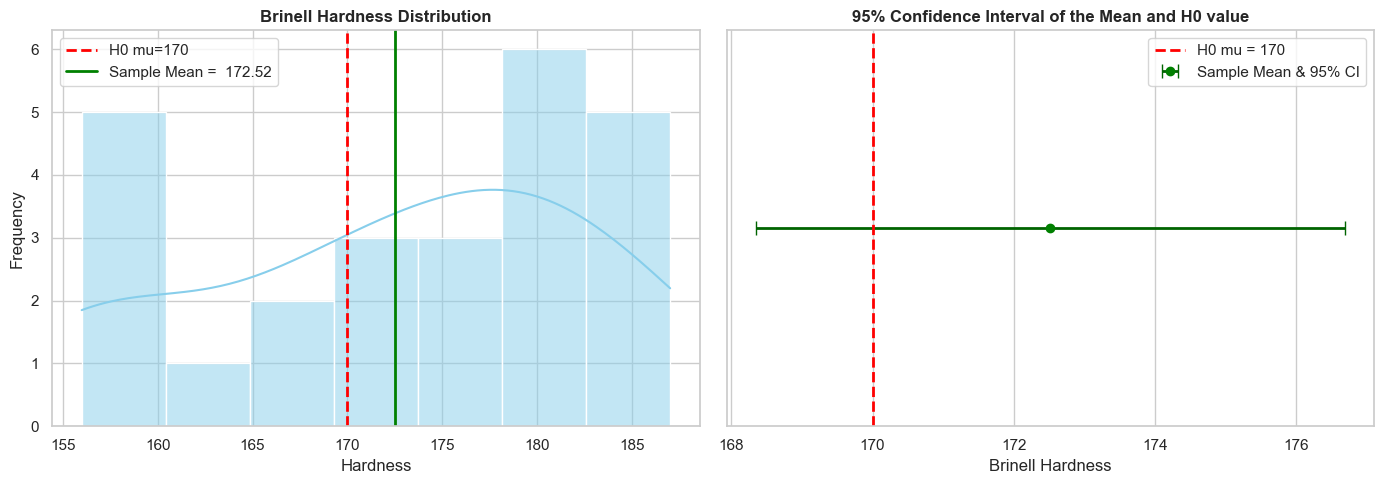

In [12]:
# Məlumatların və nəticələrin vizuallaşdırılması

# 1 sətir və 2 sütundan ibarət qrafik pəncərəsi yaradırıq.
fig, ax = plt.subplots(1,2, figsize=(14, 5))

# Sol qrafikdə Bərklik göstəricilərinin paylanması verilir:
sns.histplot(data, kde=True, ax=ax[0], color='skyblue', bins=7)
ax[0].axvline(mu_0, color='red', linestyle='--', linewidth=2, label=f'H0 mu={mu_0}')
ax[0].axvline(mean, color='green', linestyle='-', linewidth=2, label=f'Sample Mean = {mean: .2f}')
ax[0].set_title('Brinell Hardness Distribution', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Hardness')
ax[0].set_ylabel('Frequency')
ax[0].legend()


# Sağ qrafikdə isə 95% etibarlılıq intervalı və H0 dəyərinin müqayisəsi verilir:
ax[1].errorbar(x=mean, y=1, xerr=[[mean-ci_two_sided[0]], [ci_two_sided[1]-mean]],
               fmt='o', color='green', ecolor='darkgreen', elinewidth=2, capsize=5, label='Sample Mean & 95% CI')
ax[1].axvline(mu_0, color='red', linestyle='--', linewidth=2, label=f'H0 mu = {mu_0}')
ax[1].set_yticks([])
ax[1].set_title('95% Confidence Interval of the Mean and H0 value', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Brinell Hardness')
ax[1].legend()

# Qrafiklərin bir-birinə qarışmaması üçün tənzimləmə:
plt.tight_layout()
plt.show()

# **Yekun Analiz Mülahizəsi (Conclusion & Key Findings)**

**1. Təsviri Statistika və Hipotez:**

In [ ]:
# Nəticə:
# 25 çuqun nümunəsinin orta Brinell bərkliyi 172.52 HB ölçülmüşdür. Bu dəyər 170 HB hədəfindən 
# yüksək görünür, lakin t-test nəticələrinə əsasən bu fərq statistik olaraq əhəmiyyətli deyildir.
# Qərar: H0 hipotezi rədd edilmir. Məlumatlar çuqunun orta bərkliyinin 170 HB-dən böyük olduğunu 
# iddia etmək üçün kifayət qədər sübut vermir.

**2. Etibarlılıq İntervalı (%95 CI):**

In [ ]:
# Birtərəfli 95% aşağı sərhəd 169.10 HB təşkil edir. Məhsulun həqiqi ortalaması 95% ehtimalla
# bu dəyərdən böyükdür.
# 170 HB hədəf dəyəri bu interval daxilinə düşdüyü üçün prosesin standartlara cavab verdiyi
# təstiqlənir.

**3. Metodoloji Qeyd (Normallıq Şərti):**

In [ ]:
# Shapiro-Wilk normallıq testi p=0.0400 hesablayaraq datanın normal paylanmadan cüzi 
# kənara çıxdığını göstərir.
# Lakin Minitab hesabatı ilə tam uyğunluq yaratmaq və seçim həcminin kifayət qədər böyük olmasını
# nəzərə alaraq t-test nəticələri əsas götürülmüşdür.